In [122]:
import strategies
import random
from typing import Any
import numpy as np
import matplotlib.pyplot as plt
from utils import (
    LETTER_TO_MOVE,
    LETTER_TO_MOVE_PAIR,
    Move,
    MoveHistory,
    get_counter,
    get_rated_substringss_v1,
    is_suffix,
    move_list_to_str,
    move_pair_list_to_str,
    resolve_move_lists,
)
import time
from math import nan
from typing import Any

import strategies
from utils import MoveHistory, Strategy, resolve_moves

In [123]:
def simulate_game_verbose(
    round_count: int, strategy_1: Strategy, strategy_2: Strategy
) -> tuple[tuple[int, float], tuple[int, float]]:
    strategy_1_history: MoveHistory = np.empty(round_count, dtype=object)
    strategy_1_score = 0
    strategy_1_time_ms: float = 0
    context_1: Any | None = None

    strategy_2_history: MoveHistory = np.empty(round_count, dtype=object)
    strategy_2_score = 0
    strategy_2_time_ms: float = 0
    context_2: Any | None = None

    score_1_per_round = np.empty(round_count, dtype=int)
    score_2_per_round = np.empty(round_count, dtype=int)

    for i in range(round_count):
        start_time = time.time()
        move_1, context_1 = strategy_1(
            strategy_1_history[:i], strategy_2_history[:i], context_1
        )
        strategy_1_time_ms += (time.time() - start_time) * 1000

        start_time = time.time()
        move_2, context_2 = strategy_2(
            strategy_2_history[:i], strategy_1_history[:i], context_2
        )
        strategy_2_time_ms += (time.time() - start_time) * 1000

        delta_1, delta_2 = resolve_moves(move_1, move_2)

        strategy_1_score += delta_1
        strategy_2_score += delta_2
        strategy_1_history[i] = move_1
        strategy_2_history[i] = move_2

        score_1_per_round[i] = strategy_1_score
        score_2_per_round[i] = strategy_2_score

    move_to_char = {0: "R", 1: "P", 2: "S"}
    history_1_str = "".join(move_to_char[m] for m in strategy_1_history)
    history_2_str = "".join(move_to_char[m] for m in strategy_2_history)
    print(f"Strategy 1: {history_1_str}")
    print(f"Strategy 2: {history_2_str}")

    rounds = np.arange(1, round_count + 1)
    plt.plot(rounds, score_1_per_round, label="Strategy 1")
    plt.plot(rounds, score_2_per_round, label="Strategy 2")
    plt.xlabel("Round")
    plt.ylabel("Cumulative score")
    plt.legend()
    plt.show()

    return (strategy_1_score, strategy_1_time_ms), (
        strategy_2_score,
        strategy_2_time_ms,
    )

In [ ]:
def strat_pattern_beater(
    my_moves: MoveHistory, opponent_moves: MoveHistory, context: Any | None
) -> tuple[Move, Any | None]:
    """
    Plays the move that would counter what a pattern matcher would predict it
    would play. Result is that it confuses 1d pattern matchers into playing the
    the same move over and over again. Exploits this.

    Author: AugustusTheBirb
    """

    pattern_length: int = 3

    if context is None:
        context = ([], {})
    my_list, patterns = context

    # update context
    if len(my_moves) > len(my_list):
        new_move = int(my_moves[-1])
        if len(my_list) >= pattern_length:
            key = tuple(my_list[-pattern_length:])
            if key not in patterns:
                patterns[key] = {0: 0, 1: 0, 2: 0}
            patterns[key][new_move] += 1
        my_list.append(new_move)

    if len(my_moves) > 10:

        if np.all(opponent_moves[-pattern_length : ] == opponent_moves[-1]):
            return get_counter(opponent_moves[-1]), context

        key = tuple(my_list[-pattern_length:])
        d = patterns.get(key, {0: 0, 1: 0, 2: 0})

        arr = sorted(list(d.items()), key=lambda x: x[1])

        return get_counter(get_counter(arr[-1][0])), context
    else:
        return random.randint(0,2), context

In [125]:
def strat_patternmatcher_1d_v1(
    my_moves: MoveHistory,
    opponent_moves: MoveHistory,
    context: tuple[int, dict[str, float]] | None,
) -> tuple[Move, Any | None]:
    """
    A more complex strategy, which tries to find a pattern in the
    opponets moves, to defeat the opponent, it is quite dependant
    on its parameters

    Author: lukassta
    """
    if len(my_moves) == 0:
        return random.randint(0,2), None

    # ========PARAMETERS========
    MIN_SUBLIST_LENGTH = 1
    MAX_SUBLIST_LENGTH = 4
    BASE_SUBLIST_SCORE = 1
    LETTER_SCORE_MULT = 3
    # ==========================

    if context is None:
        context = (0, {})

    opponent_move_string = move_list_to_str(list(opponent_moves))

    context = get_rated_substringss_v1(
        opponent_move_string,
        min_lenght=MIN_SUBLIST_LENGTH,
        max_lenght=MAX_SUBLIST_LENGTH,
        base_score=BASE_SUBLIST_SCORE,
        letter_score_mult=LETTER_SCORE_MULT,
        context=context,
    )

    for substring in context[1]:
        if is_suffix(opponent_move_string, substring[:-1]):
            predicted_move: Move = LETTER_TO_MOVE[substring[-1]]
            counter_move: Move = get_counter(predicted_move)
            return counter_move, context

    return random.choice(list(Move)), context

Strategy 1: PRPPSRSSPRRRRSPSSSSPSPPPPPRPRRRRRSRPPPRRSRRPPPRRSSSSSSSPPRSPPRSRRRSSPPSSPRSRSPPSPRPRSSRPRPSPRPSRRRRSPSSSSPRPPRPPRPRPRRPRRPRSSSSSPSPSPSRPRSPPPSSPSRPSRRSPRRPSSPPPSPRRRRRRRSRSPRSSSSSPPRRRSSPRRSSPRSPRSPRPSSRRSPSRRPSSRRPPSSRSRPSPSRSRPPPPPPPPRRRRSPSSSSSPSPPPPPRSRRRSRRRSSSSPSPPPPPPRSRSRSSPPPPRPRRRRRSPPRRSRPPRSRPRSSRSSRSSSSPPPPRPRRRRSRSSSSPRPSPPRPSPRRSRPRSSSPRRSSPSRSPPPPPPRRRRRSSSPSRPSRPSRRSPRSPSSSPPPPPRRRRSPPRSPRSRRSRSSSSSPPPPRSRPPRPSRRPPSPRRRRSRSSSSSPRSSPRPPPRPPRRRSSPSSPSSPPRRSSPPRSSPPRSPRPPSPSPSPPRPRRRRRRRSPSRSPSRRPRSPPRRSPPSRRRSSSSSSPRPSSRPPSRPRPPPRSRPRPPRRRRSPSSSSSPRPRPRPSSPRRSRRRSSPSSRPSPPSRSPPSPPPRSRRRRSPSSSPSPPPPRPRRRRSRRSRSSSSSPSPPPPPPRPSPRRRRSRPSRSPPRRSSPPRRSSPPRRSPRRSPRSSRPPSRSPRSSRRSRSSSSPRPSRPPPRPPPRSRRRSRSSSSSPRPPPPPPRSRRRRSSSSPSPRRSSPSPPPPRSSPPRPPRPRRRRRSPRRSPSRPRSSPSRPRSSSSSPPPPRPRRRRSRPSSPPRRSRPSSSPRSPSRRSSPRPSPRPPPRRRRSSSSPRRSSPSRRSPPSRSPPSPPPPPRSRRRSPRRSPSSSPSPPPPRSRRRSRSPPRPRSSRRSRSSSPPPPRPSPRRRRSRSSSSPPPRRSSPRSPRSPRSPSRPPPPRRRRSSSSPRSPSSPSPPPPRSPPRSRRRRRSPPRPSR

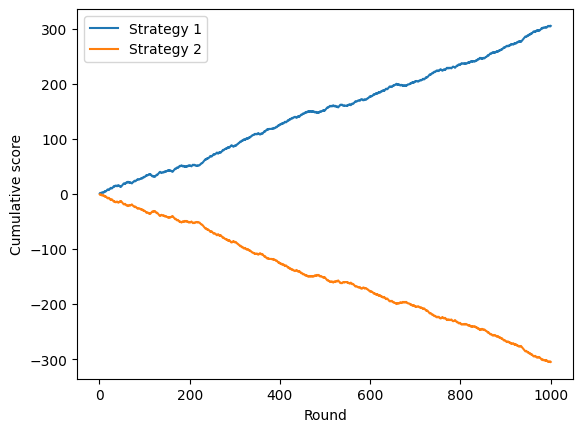

305


In [154]:
for i in range(1):
    print(simulate_game_verbose(1000, strat_pattern_beater, strategies.strat_patternmatcher_1d_v1)[0][0])